In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Task1. Data Exploration and Preprocessing

In [4]:
#Load DataSet
df = pd.read_csv("sonardataset.csv")
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [6]:
print("Dataset Shape :", df.shape)

Dataset Shape : (208, 61)


In [7]:
df.isnull().sum()

x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64

In [8]:
df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [9]:
#Class Distribution
df.iloc[:,-1].value_counts()

Y
M    111
R     97
Name: count, dtype: int64

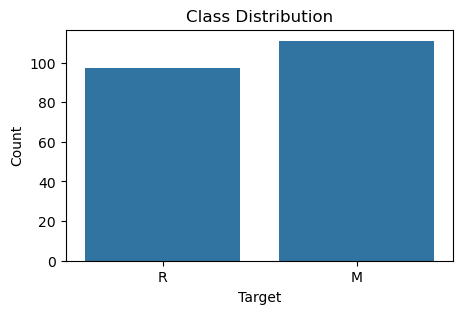

In [10]:
# Visulaization
plt.figure(figsize=(5,3))
sns.countplot(x=df.iloc[:,-1])
plt.title("Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [11]:
#checking Class Balance
print(df.iloc[:,-1].value_counts(normalize=True))

Y
M    0.533654
R    0.466346
Name: proportion, dtype: float64


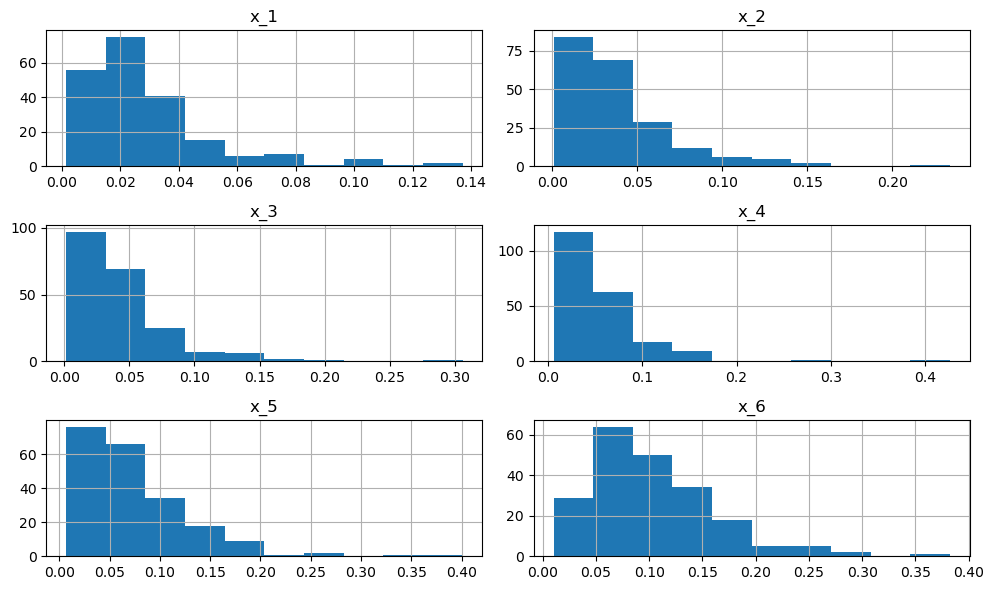

In [12]:
#Feature Distribution
df.iloc[:,:6].hist(figsize=(10,6))
plt.tight_layout()

plt.show()

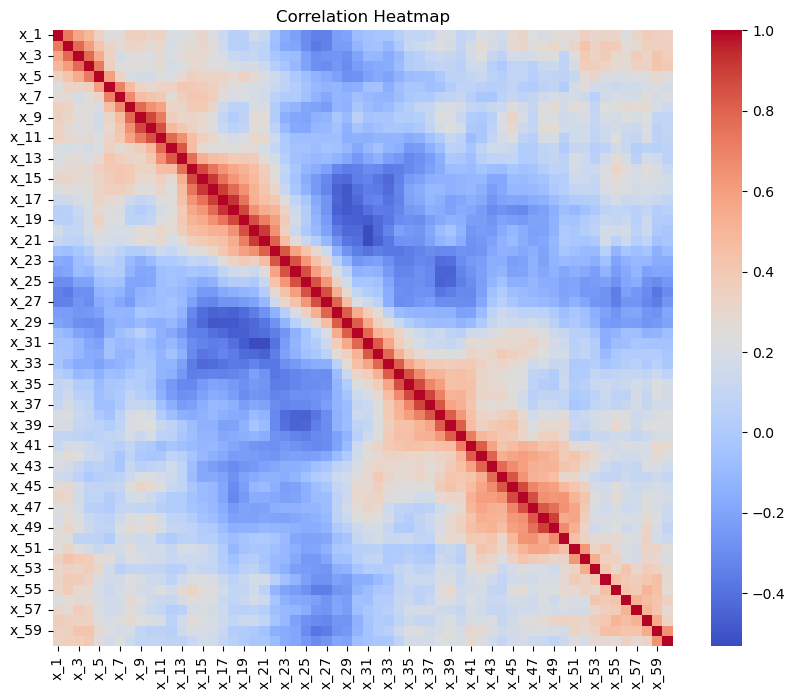

In [13]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df.iloc[:,:-1].corr(),
    cmap='coolwarm',
    cbar=True
)

plt.title("Correlation Heatmap")

plt.show()

#### Data Preprocessing

In [14]:
#Encode Target Values
le = LabelEncoder()
df.iloc[:,-1] = le.fit_transform(df.iloc[:,-1])

df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,1
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,1
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,1
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,1
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,1


In [15]:
# Separate Features and Target
X = df.iloc[:,:-1]
y = le.fit_transform(df.iloc[:, -1])
y = y.astype(int)

In [16]:
#Normalize Features
X = df.iloc[:, :-1].astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.20,random_state=42)

In [18]:
#Verifying Shapes
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (166, 60)
Testing Shape : (42, 60)


# 2. Model Implementation

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
#Build Basic ANN Model
model = Sequential()

model.add(Dense(12, input_dim=60, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 12)                  │             732 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 845 (3.30 KB)

 Trainable params: 845 (3.30 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
print(X_train.dtype)
print(y_train.dtype)

float64
int64


In [23]:
#Model Training
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=10,
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5076 - loss: 0.6914 - val_accuracy: 0.4118 - val_loss: 0.7853
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5758 - loss: 0.6522 - val_accuracy: 0.4706 - val_loss: 0.7565
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7045 - loss: 0.6179 - val_accuracy: 0.4706 - val_loss: 0.7253
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7576 - loss: 0.5880 - val_accuracy: 0.4706 - val_loss: 0.7001
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7803 - loss: 0.5575 - val_accuracy: 0.5000 - val_loss: 0.6765
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8106 - loss: 0.5283 - val_accuracy: 0.6176 - val_loss: 0.6503
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8258 - loss: 0.4991 - val_accuracy: 0.7059 - val_loss: 0.6261
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8409 - loss: 0.4700 - val_accuracy: 0.

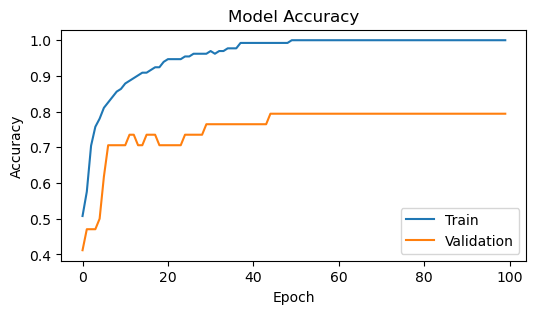

In [26]:
#Model Accuracy and Loss
#Accuracy Plot
plt.figure(figsize=(6,3))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

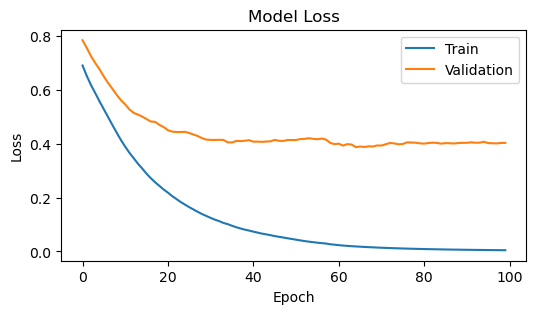

In [27]:
#Loss Plot
plt.figure(figsize=(6,3))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [28]:
#Predicting Test Data
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


In [29]:
# Model Evaluation
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.8809523809523809


In [30]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[21,  5],
       [ 0, 16]])

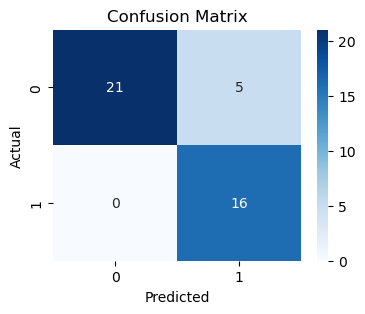

In [31]:
#HeatMap
plt.figure(figsize=(4,3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [86]:
#classification_report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.81      0.88        26
           1       0.75      0.94      0.83        16

    accuracy                           0.86        42
   macro avg       0.85      0.87      0.85        42
weighted avg       0.88      0.86      0.86        42



# Task 3: Hyperparameter Tuning

In [32]:
pip install scikeras

Note: you may need to restart the kernel to use updated packages.


In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import GridSearchCV

In [34]:
# Creating Model Function
def create_model(neurons=16,
                 activation='relu',
                 learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons,
                    input_dim=60,
                    activation=activation))

    model.add(Dense(neurons//2,
                    activation=activation))

    model.add(Dense(1,
                    activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [35]:
#Wrap The Model
ann = KerasClassifier(
    model=create_model,
    verbose=0
)

In [36]:
#Parameter Grid
param_grid = {

    'model__neurons':[8,16,32],

    'model__activation':['relu','tanh'],

    'model__learning_rate':[0.01,0.001],

    'batch_size':[10,20],

    'epochs':[100]
}

In [37]:
#Grid Search
grid = GridSearchCV(
    estimator=ann,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1

)

grid_result = grid.fit(X_train, y_train)

In [38]:
#Display Best Parameters
print("Best Accuracy :", grid_result.best_score_)
print("Best Parameters :")
print(grid_result.best_params_)

Best Accuracy : 0.8373376623376623
Best Parameters :
{'batch_size': 20, 'epochs': 100, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons': 32}


In [40]:
#Train Final Tuned Model
best_model = grid_result.best_estimator_
best_model

,model,<function cre...001D08EAE0900>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,20
,validation_batch_size,None
,verbose,0
,callbacks,None


In [41]:
#Prediction
y_pred_tuned = best_model.predict(X_test)

In [43]:
#Evaluation
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))

Accuracy : 0.9523809523809523


# Part 4: Evaluation, Comparison and Conclusion

In [44]:
# Evaluate Default ANN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

default_accuracy = accuracy_score(y_test, y_pred)
default_precision = precision_score(y_test, y_pred)
default_recall = recall_score(y_test, y_pred)
default_f1 = f1_score(y_test, y_pred)

print("Default Model Accuracy :", default_accuracy)
print("Precision :", default_precision)
print("Recall :", default_recall)
print("F1 Score :", default_f1)

Default Model Accuracy : 0.8809523809523809
Precision : 0.7619047619047619
Recall : 1.0
F1 Score : 0.8648648648648649


In [46]:
#Tunes ANN
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Model Accuracy :", tuned_accuracy)
print("Precision :", tuned_precision)
print("Recall :", tuned_recall)
print("F1 Score :", tuned_f1)

Tuned Model Accuracy : 0.9523809523809523
Precision : 0.8888888888888888
Recall : 1.0
F1 Score : 0.9411764705882353


In [47]:
#Comparison
comparison = pd.DataFrame({

    "Metric":["Accuracy","Precision","Recall","F1 Score"],

    "Default ANN":[
        default_accuracy,
        default_precision,
        default_recall,
        default_f1
    ],

    "Tuned ANN":[
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]

})

comparison

,Metric,Default ANN,Tuned ANN
0,Accuracy,0.880952,0.952381
1,Precision,0.761905,0.888889
2,Recall,1.000000,1.000000
3,F1 Score,0.864865,0.941176


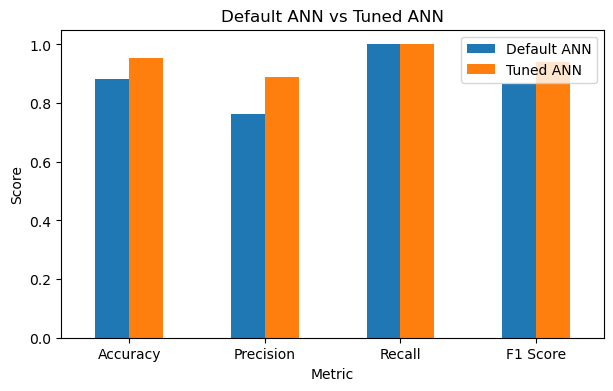

In [48]:
#Comparison Plot
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Default ANN vs Tuned ANN")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [50]:
#Best Parameters
print("Best Parameters")
print(grid_result.best_params_)
print("\nBest Cross Validation Accuracy")
print(grid_result.best_score_)

Best Parameters
{'batch_size': 20, 'epochs': 100, 'model__activation': 'relu', 'model__learning_rate': 0.001, 'model__neurons': 32}

Best Cross Validation Accuracy
0.8373376623376623


### Conclusion
## Performance Comparison:
The tuned ANN achieved 95.24% accuracy, compared to 88.10% for the default ANN, showing a significant improvement in overall classification performance.
Precision increased from 76.19% to 88.89%, while recall remained 100% for both models, indicating that the tuned model reduced false positive predictions without missing any actual mine samples.
The F1-score improved from 86.49% to 94.12%, demonstrating that hyperparameter tuning produced a more balanced and reliable model.
## Tuned model performs better:
Hyperparameter tuning improved the model by selecting the optimal number of neurons, activation function, learning rate, and batch size.
The tuned ANN achieved higher accuracy and better precision, recall, and F1-score compared to the default ANN.
This demonstrates that systematic hyperparameter tuning enhances the learning capability and generalization performance of the neural network.


### Effect of Hyperparameter Tuning:
Hyperparameter tuning optimized the network architecture by selecting the best combination of neurons, activation function, learning rate, and training parameters.
The tuned model generalized better on unseen data, resulting in higher accuracy and improved precision and F1-score.
This demonstrates that systematic hyperparameter tuning can significantly enhance ANN performance compared to using default settings.